# AdaBoost超参数优化：AdaBoostRegressor  最优超参数确定（调参）
## 超参数调优方法：网格搜索，随机搜索，贝叶斯优化等算法
### 2025.02.20 sunyu 

In [ ]:
AdaBoostRegressor 调整如下参数：
ate

# API  Default parameters
class sklearn.ensemble.AdaBoostRegressor(base_estimator=None, *, n_estimators=50, learning_rate=1.0, loss='linear', random_state=None)      )

In [1]:
#导入库
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor

from lightgbm.sklearn import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor  #GBDT

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor  #XGBoost

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Skopt functions   
from skopt import BayesSearchCV
#from skopt.callbacks import DeadlineStopper, DeltaYStopper
#from skopt.space import Real, Categorical, Integer
#No module named 'skopt':  pip install scikit-optimize

from hyperopt import fmin, tpe, hp, anneal, Trials


import timeit
import os
import psutil
import missingno as msno

In [1]:
import sklearn
print(sklearn.__version__)

1.5.1


## AdaBoost决策树回归

In [2]:
# 读取CSV文件
data = pd.read_csv('20241128_sunyu.csv',encoding='gbk',header=0)

In [92]:
#data.columns
data

,煤田,矿区,采厚,面长,走向长,推进速度,开采方式,硬岩比,覆岩类型,抗压强度,采深,煤倾,导高
0,4,4,9.10,104.0,0.143045,0.194805,6,0.010,0.4,4.78,610.00,23.0,128.74
1,4,4,12.48,98.1,0.138282,0.194805,6,0.010,0.4,4.78,634.00,21.0,133.30
2,4,4,11.00,100.0,0.133027,0.194805,1,0.010,0.4,4.78,610.00,15.0,126.10
3,35,26,12.00,200.0,0.111348,0.233766,6,0.399,0.4,10.15,552.19,4.0,239.42
4,35,26,6.50,200.0,0.111348,0.233766,6,0.399,0.6,10.15,552.00,4.5,192.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,23,32,1.80,200.0,-0.047627,-0.038961,7,0.260,0.4,15.00,146.00,5.0,15.00
276,22,31,1.20,225.0,0.174084,-0.038961,5,0.660,0.6,35.00,120.00,6.8,31.00
277,34,51,4.00,136.0,0.082115,0.220779,7,0.210,0.4,15.00,350.00,7.0,35.50
278,34,51,3.60,150.0,0.154048,0.285714,7,0.250,0.4,15.00,359.00,7.5,30.20


In [3]:
# 获取特征和目标变量
X = data.drop('导高', axis=1) #'daogao'
y = data['导高']


In [ ]:
X

In [ ]:
y

In [56]:
# 获取特征和目标变量
#data = data.drop('导高', axis=1) #'daogao'
#targets = data['导高']

In [4]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# 划分训练集和测试集
#train_data, test_data, train_targets, test_targets = train_test_split(X, y, test_size=0.20, shuffle=True,random_state=3)

In [5]:
rng = np.random.RandomState(1)

In [6]:
# Fit regression model
DT_reg = DecisionTreeRegressor(max_depth=4)

ada_reg = AdaBoostRegressor(DecisionTreeRegressor(max_depth=4),
                          n_estimators=150, random_state=rng)

In [7]:
DT_reg.fit(X_train, y_train)
ada_reg.fit(X_train, y_train)

# Predict
y1_pre = DT_reg.predict(X_test)
y2_pre = ada_reg.predict(X_test)

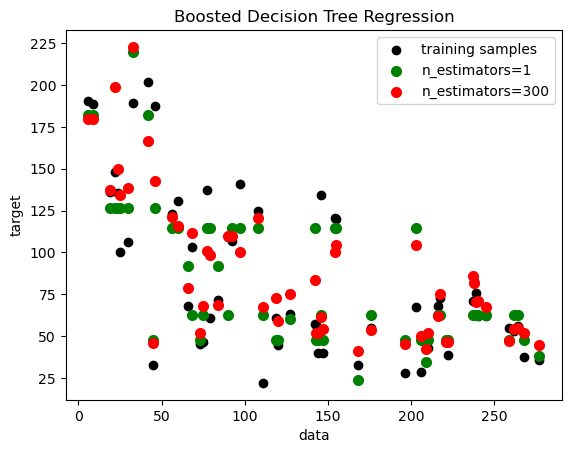

In [8]:
plt.figure()
plt.scatter(X_test.index, y_test, c="k", label="training samples")
plt.scatter(X_test.index, y1_pre, c="g", label="n_estimators=1", linewidth=2)
plt.scatter(X_test.index, y2_pre, c="r", label="n_estimators=300", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Boosted Decision Tree Regression")
plt.legend()
plt.show()

In [10]:
from yellowbrick.regressor import PredictionError,ResidualsPlot 

E:\anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but AdaBoostRegressor was fitted with feature names
  warnings.warn(


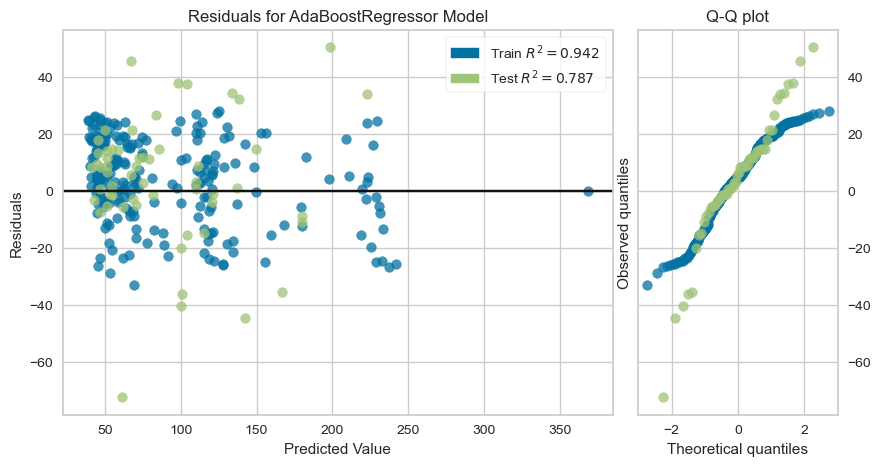

<Figure size 800x550 with 0 Axes>

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

#xgb1 = XGBRegressor(learning_rate=0.1,max_depth=2, n_estimators=138,random_state=3)

visualizer = ResidualsPlot(ada_reg, hist=False, qqplot=True,ax=ax)
#model = Ridge()
#visualizer = ResidualsPlot(model)
visualizer.fit(X_train,y_train)
visualizer.score(X_test,y_test)
g = visualizer.poof() #: 
plt.savefig("Residuals_Plot20.849_20250228.jpg",dpi=400)

In [94]:
'''
from sklearn.model_selection import KFold, cross_val_score, train_test_split

random_state = 3
n_iter = 50

train_data, test_data, train_targets, test_targets = train_test_split(X, y, test_size=0.20, shuffle=True, random_state=random_state)

num_folds = 2
kf = KFold(n_splits=num_folds) #, random_state=random_state
'''

In [5]:
#num_folds=2
#random_state=3
#kf = KFold(n_splits=num_folds) #, random_state=3

# AdaBoostRegressor and GridSearch

In [11]:
'''
param_grid={'learning_rate': np.logspace(-4, 0, 5),
            'max_depth':  np.linspace(1,20,20,dtype = int),#最大深度的选择, 从1到20，步长为1
            'n_estimators': np.linspace(1,150,150, dtype = int),
            'subsample': np.linspace(0.1, 1.0, 10),
            #'min_child_weight': [1,3,5],
            #'colsample_bytree':np.linspace(0.1, 1.0, 10), # subsample ratio of columns by tree
            #'max_delta_step': np.linspace(0.1, 1.0, 10),
            'max_features': ['sqrt','log2',None] ,#range(1, 10, 1),  # 从1到12，步长为1
            'gamma':np.linspace(0,100,101, dtype = int),
            
            'reg_alpha': np.logspace(-4, 1, 10), # L1 regularization
            'reg_lambda': np.linspace(0,50,51),# L2 regularization
           }
'''

In [5]:
#param_grid={#'learning_rate': np.logspace(-4, 0, 5),
           # 'max_depth':  np.linspace(1,10,10,dtype = int),#最大深度的选择, 从1到20，步长为1
           # 'n_estimators': np.linspace(1,150,150, dtype = int),
            #'subsample': np.linspace(0.1, 1.0, 10),
            #'min_child_weight': [1,3,5],
            #'colsample_bytree':np.linspace(0.1, 1.0, 10), # subsample ratio of columns by tree
            #'max_delta_step': np.linspace(0.1, 1.0, 10),
            #'max_features': ['sqrt','log2',None] ,#range(1, 10, 1),  # 从1到12，步长为1
            #'gamma':np.linspace(0,100,101, dtype = int),
            
            #'reg_alpha': np.logspace(-4, 1, 10), # L1 regularization
            #'reg_lambda': np.linspace(0,50,51),# L2 regularization
#           }

In [19]:
#'learning_rate': np.logspace(-4, 0, 5),
#'max_depth':  np.linspace(1,10,10,dtype = int),#最大深度的选择, 从1到20，步长为1
#'n_estimators': np.linspace(30,150,120, dtype = int),
#此程序运行占内存10.5234375mB
#Running time:141.36394s
#Best MSE 734.860 params {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 138}
#时间占用 s
start=timeit.default_timer()
#内存占用 mb
info_start = psutil.Process(os.getpid()).memory_info().rss/1024/1024
# MemoryError 当参数过多，就出现内存错误
param_grid={'learning_rate': np.logspace(-4, 0, 5),
            'loss':  ['linear','square','exponential'],
            'n_estimators': np.linspace(30,150,120, dtype = int),
            #'subsample': np.linspace(0.1, 1.0, 10),  #Best MSE 780.007 params {'learning_rate': 0.1, 'n_estimators': 109, 'subsample': 0.4}
            #'min_child_weight': [1,3,5],
            #'colsample_bytree':np.linspace(0.1, 1.0, 10), # subsample ratio of columns by tree
            #'max_delta_step': np.linspace(0.1, 1.0, 10),
            #'gamma':np.linspace(0,100,101, dtype = int),
            #'reg_alpha': np.logspace(-4, 1, 5), # L1 regularization
            #'reg_lambda': np.linspace(0,50,51)# L2 regularization    MSE 875.392
           }
ada = AdaBoostRegressor(random_state=3)
gs=GridSearchCV(ada, param_grid, scoring='neg_mean_squared_error', #fit_params=None, 
                n_jobs=-1, cv=5, verbose=1)
gs.fit(X_train, y_train)
gs_test_score=mean_squared_error(y_test, gs.predict(X_test))

end=timeit.default_timer()
info_end = psutil.Process(os.getpid()).memory_info().rss/1024/1024

print('此程序运行占内存'+str(info_end-info_start)+'mB')
print('Running time:%.5fs'%(end-start))
print("Best MSE {:.3f} params {}".format(-gs.best_score_, gs.best_params_))

Fitting 5 folds for each of 1800 candidates, totalling 9000 fits
此程序运行占内存6.8125mB
Running time:296.87006s
Best MSE 946.074 params {'learning_rate': 0.1, 'loss': 'exponential', 'n_estimators': 107}


E:\anaconda\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [20]:
# Fit regression model
DT_reg = DecisionTreeRegressor(max_depth=3)

ada_reg = AdaBoostRegressor(DecisionTreeRegressor(max_depth=3),
                          n_estimators=107, learning_rate=0.1,loss='exponential',random_state=rng)

In [21]:
DT_reg.fit(X_train, y_train)
ada_reg.fit(X_train, y_train)

# Predict
#y1_pre = DT_reg.predict(X_test)
y_pred = ada_reg.predict(X_test)

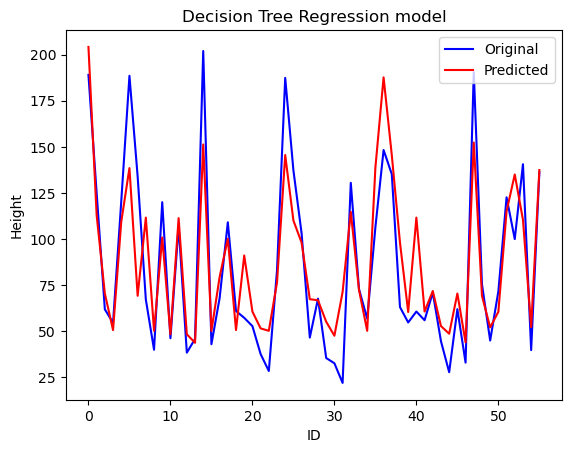

In [23]:
plt.plot(range(y_test.shape[0]),y_test, color='b', label='Original')
plt.plot(range(y_test.shape[0]),y_pred, color='r', label='Predicted')
plt.title('Decision Tree Regression model')
#plt.xticks(np.arange(0, round(X_test.shape[0] * 0.3), t), X_test)
plt.xlabel('ID')
plt.ylabel('Height')
plt.legend(loc='upper right')
plt.show()

In [99]:
'''
#时间占用 s
start=timeit.default_timer()
#内存占用 mb
info_start = psutil.Process(os.getpid()).memory_info().rss/1024/1024

param_grid={'learning_rate': np.logspace(-3, -1, 10),
            'max_depth':  np.linspace(1,10,10,dtype = int),#最大深度的选择, 从1到20，步长为1
            'n_estimators': np.linspace(30,150,120, dtype = int),
            'booster':['gbtree','dart','gblinear'],
#            'subsample': np.linspace(0.1, 1.0, 10),
#            'min_child_weight': [1,3,5],
#            'colsample_bytree':np.linspace(0.1, 1.0, 10), # subsample ratio of columns by tree
#            'max_delta_step': np.linspace(0.1, 1.0, 10),
#            'max_features': ['sqrt','log2',None] ,#range(1, 10, 1),  # 从1到12，步长为1
#            'gamma':np.linspace(0,100,101, dtype = int),
            
#            'reg_alpha': np.logspace(-4, 1, 10), # L1 regularization
#            'reg_lambda': np.linspace(0,50,51),# L2 regularization
           }
xgb = AdaBoostRegressor(random_state=3)
gs=GridSearchCV(xgb, param_grid, scoring='neg_mean_squared_error', #fit_params=None, 
                n_jobs=-1, cv=kf, verbose=False)
gs.fit(train_data, train_targets)
gs_test_score=mean_squared_error(test_targets, gs.predict(test_data))

end=timeit.default_timer()
info_end = psutil.Process(os.getpid()).memory_info().rss/1024/1024

print('此程序运行占内存'+str(info_end-info_start)+'mB')
print('Running time:%.5fs'%(end-start))
print("Best MSE {:.3f} params {}".format(-gs.best_score_, gs.best_params_))
'''

此程序运行占内存-34.0625mB
Running time:1420.81161s
Best MSE 734.860 params {'booster': 'gbtree', 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 138}


In [18]:
'''
# iteration 2 find other parameters 
param_grid={#'learning_rate': np.logspace(-3, -1, 10),
            #'max_depth':  np.linspace(1,10,10,dtype = int),#最大深度的选择, 从1到20，步长为1
            #'n_estimators': np.linspace(30,150,120, dtype = int),
            'subsample': np.linspace(0.1, 1.0, 10),
            'min_child_weight': [1,3,5],
            'colsample_bytree':np.linspace(0.1, 1.0, 10), # subsample ratio of columns by tree
            'max_delta_step': np.linspace(0.1, 1.0, 10),
            'booster':['gbtree','dart','gblinear'],
#            'max_features': ['sqrt','log2',None] ,#range(1, 10, 1),  # 从1到12，步长为1
#            'gamma':np.linspace(0,100,101, dtype = int),
            
#            'reg_alpha': np.logspace(-4, 1, 10), # L1 regularization
#            'reg_lambda': np.linspace(0,50,51),# L2 regularization
           }
xgb = AdaBoostRegressor(learning_rate=0.1,max_depth=2,n_estimators=138,random_state=3)
gs=GridSearchCV(xgb, param_grid, scoring='neg_mean_squared_error', #fit_params=None, 
                n_jobs=-1, cv=kf, verbose=False)
gs.fit(train_data, train_targets)
gs_test_score=mean_squared_error(test_targets, gs.predict(test_data))

print("Best MSE {:.3f} params {}".format(-gs.best_score_, gs.best_params_))
'''

Best MSE 2697.912 params {'colsample_bytree': 0.8, 'max_delta_step': 1.0, 'min_child_weight': 5, 'subsample': 0.8}


In [62]:
'''
# iteration 3 find other parameters 
param_grid={'learning_rate': np.logspace(-3, -1, 10),
            'max_depth':  np.linspace(1,10,10,dtype = int),#最大深度的选择, 从1到20，步长为1
            'n_estimators': np.linspace(30,150,120, dtype = int),
#            'subsample': np.linspace(0.1, 1.0, 10),
#            'min_child_weight': [1,3,5],
#            'colsample_bytree':np.linspace(0.1, 1.0, 10), # subsample ratio of columns by tree
#            'max_delta_step': np.linspace(0.1, 1.0, 10),
            #'gamma':np.linspace(0,100,101, dtype = int),       
            #'reg_alpha': np.logspace(-4, 1, 10), # L1 regularization
            #'reg_lambda': np.linspace(0,50,51),# L2 regularization
           }
xgb = AdaBoostRegressor(#learning_rate=0.1,max_depth=2,n_estimators=138,subsample=0.8,min_child_weight=5,max_delta_step=1.0,colsample_bytree=0.8,random_state=3
)
gs=GridSearchCV(xgb, param_grid, scoring='neg_mean_squared_error', #fit_params=None, 
                n_jobs=-1, cv=kf, verbose=False)
gs.fit(train_data, train_targets)
gs_test_score=mean_squared_error(test_targets, gs.predict(test_data))

print("Best MSE {:.3f} params {}".format(-gs.best_score_, gs.best_params_))
'''

Best MSE 734.860 params {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 138}


In [11]:
xgb

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None, max_delta=1.0,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=138, n_jobs=None,
             num_parallel_tree=None, ...)

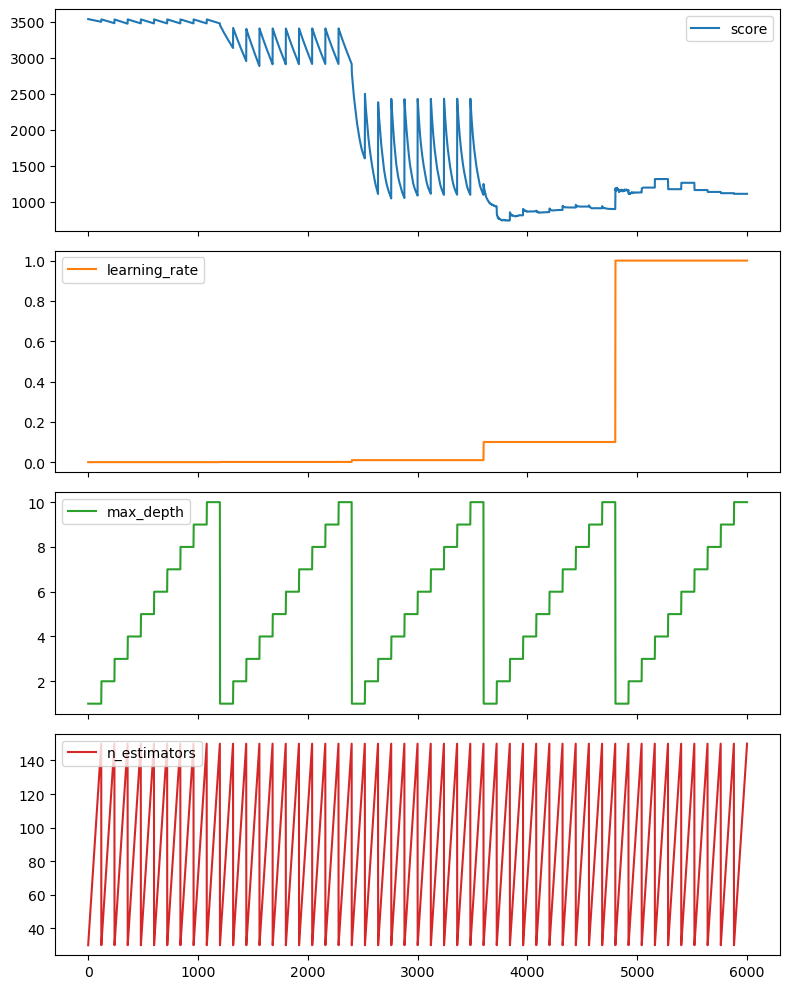

In [97]:
import matplotlib.pyplot as plt
gs_results_df=pd.DataFrame(np.transpose([-gs.cv_results_['mean_test_score'],
                                         gs.cv_results_['param_learning_rate'].data,
                                         gs.cv_results_['param_max_depth'].data,
                                         gs.cv_results_['param_n_estimators'].data]),
                           columns=['score', 'learning_rate', 'max_depth', 'n_estimators'])
gs_results_df.plot(subplots=True,figsize=(8, 10))
plt.tight_layout()  # 调整布局，防止内容被裁剪
plt.savefig('AdaBoost_tuningParas214.png', dpi=300)  # 保存为300DPI的图片
plt.show()

In [98]:
gs_results_df

,score,learning_rate,max_depth,n_estimators
0,3537.999927,0.0001,1.0,30.0
1,3537.683175,0.0001,1.0,31.0
2,3537.366454,0.0001,1.0,32.0
3,3537.049876,0.0001,1.0,33.0
4,3536.733328,0.0001,1.0,34.0
...,...,...,...,...
5995,1107.319608,1.0000,10.0,145.0
5996,1107.319608,1.0000,10.0,146.0
5997,1107.319608,1.0000,10.0,147.0
5998,1107.319608,1.0000,10.0,148.0


Text(0, 0.5, 'best_cumulative_score')

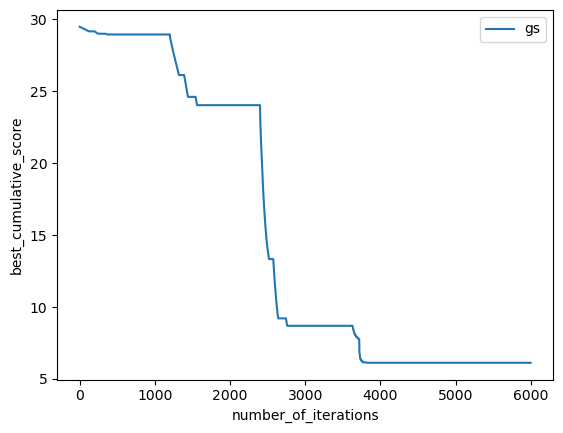

In [76]:
scores_df_gs = pd.DataFrame(index=range(n_iter*120))
scores_df_gs["gs"] = gs_results_df["score"].cummin()
ax = scores_df_gs.plot()

ax.set_xlabel("number_of_iterations")
ax.set_ylabel("best_cumulative_score")

In [58]:
gs_results_df["score"]

0       3537.999927
1       3537.683175
2       3537.366454
3       3537.049876
4       3536.733328
           ...     
5995    1107.319608
5996    1107.319608
5997    1107.319608
5998    1107.319608
5999    1107.319608
Name: score, Length: 6000, dtype: float64

In [24]:
'''
# 设置需要调优的超参数
param_grid = {
    
#    'learning_rate': np.linspace(0.001,0.1,10), #== 'eta':np.linspace(0.001,0.1,10),
#    'n_estimators' : range(10, 100, 5), # 估计器数量范围
#    'subsample': np.linspace(0.1, 1.0, 10),
#    'min_child_weight': [1,2,3,4,5,6],
#    'colsample_bytree':[0.5,0.7],
#    'gamma': np.linspace(0,100),
#    'alpha': np.linspace(0.1,0.9,9),
#    'max_depth' : range(1, 10, 1) , #最大深度的选择, 从10到200，步长为1
#    'max_features' : ['sqrt','log2',None] #range(1, 10, 1),  # 从1到12，步长为1
#    'min_samples_split' : range(2, 10, 1) , # 最小分割样本数量, 从2到100，步长为1
#    'min_samples_leaf' : range(1, 50, 1),  # 从1到100，步长为1
#    'max_leaf_nodes' : range(2, 30, 1),  # 从2到100，步长为1
#    'min_impurity_decrease': np.linspace(0.1,0.9,9),
#    'random_state' : range(0, 50, 1) , # 从0到50，步长为1
#    'objective':['reg:squarederror']
    'scale_pos_weight':np.linspace(0.1,1.0,10),
}
'''

In [8]:
'''
xgb = AdaBoostRegressor(learning_rate=0.067,n_estimators = 95,subsample=0.3,max_depth=9,random_state=3)  #max_features=5,learning_rate=0.02,
grid_search = GridSearchCV(estimator = xgb, param_grid = param_grid,  scoring='neg_mean_squared_error',  n_jobs = -1,verbose = 1)#cv = 5, verbose =2,'r2'
grid_search.fit(X_train, y_train)
'''

"\nxgb = XGBRegressor(learning_rate=0.067,n_estimators = 95,subsample=0.3,max_depth=9,random_state=3)  #max_features=5,learning_rate=0.02,\ngrid_search = GridSearchCV(estimator = xgb, param_grid = param_grid,  scoring='neg_mean_squared_error',  n_jobs = -1,verbose = 1)#cv = 5, verbose =2,'r2'\ngrid_search.fit(X_train, y_train)\n"

In [22]:
'''
#best params 2025.02.14 Best MSE 2650.049 
xgb = AdaBoostRegressor(learning_rate=0.1,n_estimators = 138,subsample=0.8,max_depth=2,colsample_bytree=0.8, max_delta_step=1.0, min_child_weight=5, gamma=0, max_features='sqrt', reg_alpha=10.0, reg_lambda=8.0,random_state=3)  #max_features=5,learning_rate=0.02,
#grid_search = GridSearchCV(estimator = xgb, param_grid = param_grid,  scoring='neg_mean_squared_error',  n_jobs = -1,verbose = 1)#cv = 5, verbose =2,'r2'
#grid_search.fit(X_train, y_train)
xgb.fit(train_data,train_targets)
gs_test_score=mean_squared_error(test_targets, xgb.predict(test_data))
print("Best MSE {:.3f} ".format(gs_test_score))
'''

Best MSE 2650.049 


E:\anaconda\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:32:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "max_features" } are not used.

  warnings.warn(smsg, UserWarning)


In [1]:
# grid_search.best_params_

In [ ]:
# Best params

# RandomsizeSearch

In [54]:
from scipy.stats import randint
param_grid_rand={
    'learning_rate': np.logspace(-4, 0, 100),
    'max_depth':  randint(2,10),
    'n_estimators': randint(10,150),
    'random_state': [3,10]
}

xgb=AdaBoostRegressor()
rs = RandomizedSearchCV(
    xgb,
    param_grid_rand,
    n_iter=n_iter,
    scoring="neg_mean_squared_error",
    #fit_params=None,
    n_jobs=-1,
    cv=kf,
    verbose=1,
    random_state=random_state,
)

rs.fit(train_data, train_targets)

rs_test_score = mean_squared_error(test_targets, rs.predict(test_data))

print("Best MSE {:.3f} params {}".format(-rs.best_score_, rs.best_params_))

Fitting 2 folds for each of 50 candidates, totalling 100 fits
Best MSE 730.635 params {'learning_rate': 0.15556761439304723, 'max_depth': 2, 'n_estimators': 47, 'random_state': 3}


In [50]:
#Best MSE 745.990 params {'learning_rate': 0.08902150854450393, 'max_depth': 2, 'n_estimators': 122, 'random_state': 3}
#Best MSE 760.308 params {'learning_rate': 0.10974987654930568, 'max_depth': 2, 'n_estimators': 145, 'random_state': 3}
#时间占用 s
start=timeit.default_timer()
#内存占用 mb
info_start = psutil.Process(os.getpid()).memory_info().rss/1024/1024
rs=RandomizedSearchCV(xgb, param_grid_rand, n_iter = 10, scoring='neg_mean_squared_error', #fit_params=None, 
                n_jobs=-1, cv=5,  random_state=5) #best_cumulative_score

rs.fit(train_data, train_targets)

rs_test_score=mean_squared_error(test_targets, rs.predict(test_data))
end=timeit.default_timer()
info_end = psutil.Process(os.getpid()).memory_info().rss/1024/1024

print('此程序运行占内存'+str(info_end-info_start)+'mB')
print('Running time:%.5fs'%(end-start))
print("Best MSE {:.3f} params {}".format(-rs.best_score_, rs.best_params_))


Fitting 5 folds for each of 10 candidates, totalling 50 fits
此程序运行占内存0.00390625mB
Running time:0.80222s
Best MSE 780.922 params {'learning_rate': 0.08902150854450393, 'max_depth': 2, 'n_estimators': 122, 'random_state': 3}


In [28]:
'''
# iteration 2 find other parameters 
param_grid_rand={#'learning_rate': np.logspace(-3, -1, 10),
            #'max_depth':  np.linspace(1,10,10,dtype = int),#最大深度的选择, 从1到20，步长为1
            #'n_estimators': np.linspace(30,150,120, dtype = int),
            'subsample': np.linspace(0.1, 1.0, 10),
            'min_child_weight': [1,3,5],
            'colsample_bytree':np.linspace(0.1, 1.0, 10), # subsample ratio of columns by tree
            'max_delta_step': np.linspace(0.1, 1.0, 10),
#            'max_features': ['sqrt','log2',None] ,#range(1, 10, 1),  # 从1到12，步长为1
#            'gamma':np.linspace(0,100,101, dtype = int),
            
#            'reg_alpha': np.logspace(-4, 1, 10), # L1 regularization
#            'reg_lambda': np.linspace(0,50,51),# L2 regularization
           }
xgb = AdaBoostRegressor(learning_rate=1.0,max_depth=5,n_estimators=145,random_state=3)
rs=RandomizedSearchCV(xgb, param_grid_rand, n_iter = 50, scoring='neg_mean_squared_error', #fit_params=None, 
                n_jobs=-1, cv=kf, verbose=False, random_state=random_state)
rs.fit(train_data, train_targets)
rs_test_score=mean_squared_error(test_targets, rs.predict(test_data))

print("Best MSE {:.3f} params {}".format(-rs.best_score_, rs.best_params_))
'''

Best MSE 916.443 params {'subsample': 0.4, 'min_child_weight': 5, 'max_delta_step': 0.9, 'colsample_bytree': 0.9}


In [13]:
'''
# iteration 3 find other parameters 
param_grid_rand={'learning_rate': np.logspace(-3, -1, 10),
            #'max_depth':  np.linspace(1,10,10,dtype = int),#最大深度的选择, 从1到20，步长为1
            #'n_estimators': np.linspace(30,150,120, dtype = int),
#            'subsample': np.linspace(0.1, 1.0, 10),
#            'min_child_weight': [1,3,5],
#            'colsample_bytree':np.linspace(0.1, 1.0, 10), # subsample ratio of columns by tree
#            'max_delta_step': np.linspace(0.1, 1.0, 10),
#            'max_features': ['sqrt','log2',None] ,#range(1, 10, 1),  # 从1到12，步长为1
            'gamma':np.linspace(0,100,101, dtype = int),
            
            'reg_alpha': np.logspace(-4, 1, 10), # L1 regularization
            'reg_lambda': np.linspace(0,50,51),# L2 regularization
           }
xgb = AdaBoostRegressor(learning_rate=1.0,max_depth=5,n_estimators=145,subsample=0.4,min_child_weight=5,max_delta=0.9,colsample_bytree=0.9,random_state=3)
rs=RandomizedSearchCV(xgb, param_grid_rand, scoring='neg_mean_squared_error', #fit_params=None, 
                n_jobs=-1, cv=kf, verbose=False)
rs.fit(train_data, train_targets)
rs_test_score=mean_squared_error(test_targets, rs.predict(test_data))

print("Best MSE {:.3f} params {}".format(-rs.best_score_, rs.best_params_))
'''

Best MSE 759.761 params {'reg_lambda': 4.0, 'reg_alpha': 0.004641588833612782, 'learning_rate': 0.1, 'gamma': 60}


E:\anaconda\Lib\site-packages\xgboost\core.py:158: UserWarning: [20:43:45] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "max_delta" } are not used.

  warnings.warn(smsg, UserWarning)


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

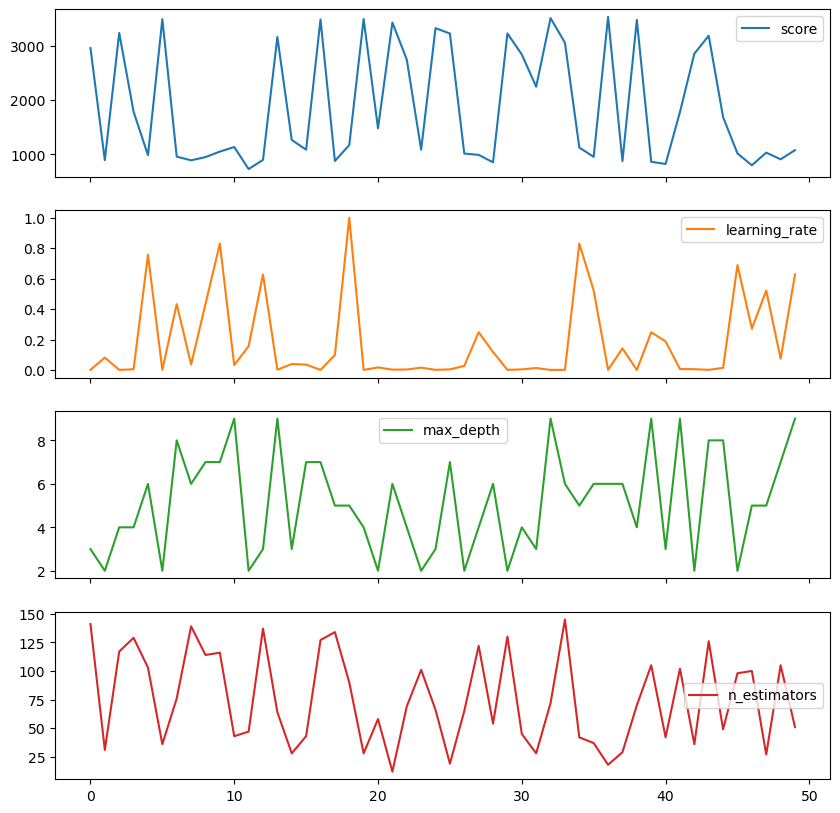

In [99]:
import matplotlib.pyplot as plt
rs_results_df=pd.DataFrame(np.transpose([-rs.cv_results_['mean_test_score'],
                                         rs.cv_results_['param_learning_rate'].data,
                                         rs.cv_results_['param_max_depth'].data,
                                         rs.cv_results_['param_n_estimators'].data]),
                           columns=['score', 'learning_rate', 'max_depth', 'n_estimators'])
rs_results_df.plot(subplots=True, figsize=(10, 10))

Text(0, 0.5, 'best_cumulative_score')

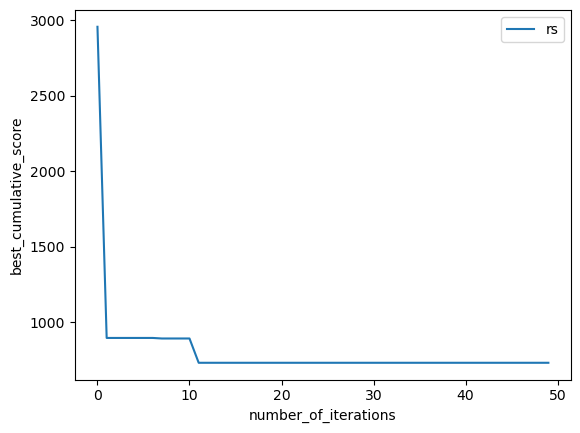

In [100]:
scores_df = pd.DataFrame(index=range(n_iter))
scores_df["rs"] = rs_results_df["score"].cummin()
ax = scores_df.plot()

ax.set_xlabel("number_of_iterations")
ax.set_ylabel("best_cumulative_score")

In [12]:
'''
import matplotlib.pyplot as plt
rs_results_df=pd.DataFrame(np.transpose([-rs.cv_results_['mean_test_score'],
                                         rs.cv_results_['param_learning_rate'].data,
                                         rs.cv_results_['param_max_depth'].data,
                                         rs.cv_results_['param_n_estimators'].data,
                                         rs.cv_results_['param_subsample'].data,
                                         rs.cv_results_['param_min_child_weight'].data,
                                         rs.cv_results_['param_colsample_ratio'].data,
                                         rs.cv_results_['param_max_delta_step'].data,
                                         rs.cv_results_['param_gamma'].data,
                                         rs.cv_results_['param_reg_alpha'].data,
                                         rs.cv_results_['param_reg_lambda'].data]),
                           columns=['score', 'learning_rate', 'max_depth', 'n_estimators',
                                    'subsample','min_child_weight','colsample_ratio','max_delta_step','gamma','reg_alpha','reg_lambda'])
rs_results_df.plot(subplots=True,figsize=(21, 10))
plt.tight_layout()  # 调整布局，防止内容被裁剪
plt.savefig('AdaBoost_tuningParas_RS_214.png', dpi=300)  # 保存为300DPI的图片
plt.show()
'''

"\nimport matplotlib.pyplot as plt\nrs_results_df=pd.DataFrame(np.transpose([-rs.cv_results_['mean_test_score'],\n                                         rs.cv_results_['param_learning_rate'].data,\n                                         rs.cv_results_['param_max_depth'].data,\n                                         rs.cv_results_['param_n_estimators'].data,\n                                         rs.cv_results_['param_subsample'].data,\n                                         rs.cv_results_['param_min_child_weight'].data,\n                                         rs.cv_results_['param_colsample_ratio'].data,\n                                         rs.cv_results_['param_max_delta_step'].data,\n                                         rs.cv_results_['param_gamma'].data,\n                                         rs.cv_results_['param_reg_alpha'].data,\n                                         rs.cv_results_['param_reg_lambda'].data]),\n                           columns=['score

# Bayesian Optimization with AdaBoost

## TPE

In [101]:
from hyperopt import fmin, tpe, hp, anneal, Trials

可用的 hyperopt 优化算法包括 -
hp.choice(label, options) — 返回其中一个选项，该选项应为列表或元组。
hp.randint(label, upper) — 返回范围 [0, upper) 之间的随机整数。
hp.uniform(label, low, high) — 返回介于 low 和 high 之间的均匀值。
hp.quniform(label, low, high, q) — 返回值 round(uniform(low, high) / q) * q，即对小数值进行四舍五入并返回一个整数。
hp.normal(label, mean, std) — 返回具有平均值和标准差 sigma 的正态分布的实值。

In [102]:
def gb_mse_cv(params, random_state=random_state, cv=kf, X=train_data, y=train_targets):
    # the function gets a set of variable parameters in "param"
    params = {'n_estimators': int(params['n_estimators']), 
              'max_depth': int(params['max_depth']), 
              'learning_rate': params['learning_rate'],
              #'subsample': params['subsample'],
              #'min_child_weight': params['min_child_weight'],
              #'colsample_bytree':params['colsample_bytree'], # subsample ratio of columns by tree
              #'max_delta_step': params['max_delta_step'],
             #'max_features': params['max_features'] ,#range(1, 10, 1),  # 从1到12，步长为1
             #'gamma':params['gamma'],            
             #'reg_alpha': params['reg_alpha'], # L1 regularization
             #'reg_lambda': params['reg_lambda'],# L2 regularization
             # 'booster':params['booster']
             }
    
    # we use this params to create a new LGBM Regressor
    xgb = AdaBoostRegressor(random_state=random_state, **params)
    
    # and then conduct the cross validation with the same folds as before
    score = -cross_val_score(xgb, X, y, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1).mean()
    print(score,params)

    return score

In [23]:
#Best MSE 752.202 params {'learning_rate': 0.08316060553979136, 'max_depth': 2.0, 'n_estimators': 96.0}
#Best MSE 3547.530 params {'colsample_bytree': 0.0, 'max_delta_step': 0.0, 'min_child_weight': 4.0, 'subsample': 0.0}
#Best MSE 816.804 params {'gamma': 4.772389046420221, 'reg_alpha': 72.0, 'reg_lambda': 0.10478729061580111}
# Best MSE 3547.530 params {'colsample_bytree': 0.0, 'gamma': 8.946919502838902, 'learning_rate': 0.06992132555536061, 'max_delta_step': 0.0, 
# 'max_depth': 9.0, 'min_child_weight': 0.0, 'n_estimators': 100.0, 'reg_alpha': 50.0, 'reg_lambda': 0.6536912918472014, 'subsample': 0.0}
# 状态空间，最小化函数的params的取值范围
space={'n_estimators': hp.quniform('n_estimators', 30, 150, 1),
       #'booster':hp.choice('booster',['gbtree','dart','gblinear']),
       'max_depth' : hp.quniform('max_depth', 2, 10, 1),
       'learning_rate': hp.loguniform('learning_rate', -5, 0),
       #'subsample': hp.quniform('subsample', 0.1, 1.0, 10),
       #'min_child_weight': hp.quniform('min_child_weight',1,7,4),
       #'colsample_bytree': hp.quniform('colsample_bytree',0.1, 1.0, 10), # subsample ratio of columns by tree
      # 'max_delta_step': hp.quniform('max_delta_step',0.1, 1.0, 10),
       #'max_features':hp.choice('max_features',['auto','sqrt','log2',None]), 
#       'gamma':hp.uniform('gamma',1,9),            
#       'reg_alpha': hp.quniform('reg_alpha',40, 100,1), # L1 regularization
#       'reg_lambda': hp.uniform('reg_lambda',0,1)# L2 regularization
       
      }
'''
xgb_params_space = {'eta': hp.uniform('eta', 0.0, 0.3), 'gamma': hp.uniform('gamma', 0.0, 0.5), 'max_depth': hp.quniform('max_depth', 2, 8, 1),
'min_child_weight': hp.quniform('min_child_weight', 1, 5, 1), 'subsample': 1, 'colsample_bytree': 1, 'colsample_bylevel': 1, 
'colsample_bynode': 1,'lambda': hp.uniform('lambda', 0.0, 1.0), 'alpha': hp.uniform('alpha', 0.0, 1.0), 'scale_pos_weight': 1.0, 
'silent': 1, 'objective': 'binary:logitraw','nthread': 1, 'eval_metric': 'auc'}
'''
# trials 会记录一些信息
trials = Trials()
#时间占用 s
start=timeit.default_timer()
#内存占用 mb
info_start = psutil.Process(os.getpid()).memory_info().rss/1024/1024
best=fmin(fn=gb_mse_cv, # function to optimize
          space=space, 
          algo=tpe.suggest, # optimization algorithm, hyperotp will select its parameters automatically
          max_evals=50, # maximum number of iterations
          trials=trials, # logging
          rstate=np.random.default_rng(random_state) # fixing random state for the reproducibility, np.random.RandomState() no passed
         )
print('best:')
print(best)
# computing the score on the test set
#random_state=random_state, n_estimators=int(best['n_estimators']),max_depth=int(best['max_depth']),learning_rate=best['learning_rate'],
xgb = AdaBoostRegressor(#random_state=3, n_estimators=96,max_depth=2,learning_rate=0.0832,
                  n_estimators=int(best['n_estimators']),max_depth=int(best['max_depth']),learning_rate=best['learning_rate'],
                 # subsample=best['subsample'],colsample_bytree=best['colsample_bytree'], max_delta_step=best['max_delta_step'], 
                 #  min_child_weight=best['min_child_weight'],#, max_features=best['max_features'],
                   #gamma=best['gamma'],  reg_alpha=best['reg_alpha'], reg_lambda=best['reg_lambda']#,booster=best['booster']
                  )
xgb.fit(train_data,train_targets)
tpe_test_score=mean_squared_error(test_targets, xgb.predict(test_data))
end=timeit.default_timer()
info_end = psutil.Process(os.getpid()).memory_info().rss/1024/1024

print('此程序运行占内存'+str(info_end-info_start)+'mB')
print('Running time:%.5fs'%(end-start))
print("Best MSE {:.3f} params {}".format( gb_mse_cv(best), best))

980.6139861322746                                                                                                      
{'n_estimators': 136, 'max_depth': 7, 'learning_rate': 0.015495281324132052}                                           
901.0467981340637                                                                                                      
{'n_estimators': 127, 'max_depth': 8, 'learning_rate': 0.034690446628733676}                                           
1131.0459239661977                                                                                                     
{'n_estimators': 62, 'max_depth': 4, 'learning_rate': 0.8979089839975195}                                              
1278.5638894202525                                                                                                     
{'n_estimators': 128, 'max_depth': 9, 'learning_rate': 0.008548239797729151}                                           
886.5835034235829                       

"\nrs_results_df=pd.DataFrame(np.transpose([-rs.cv_results_['mean_test_score'],\n                                         rs.cv_results_['param_learning_rate'].data,\n                                         rs.cv_results_['param_max_depth'].data,\n                                         rs.cv_results_['param_n_estimators'].data]),\n                           columns=['score', 'learning_rate', 'max_depth', 'n_estimators'])\nrs_results_df.plot(subplots=True, figsize=(10, 10))\n"

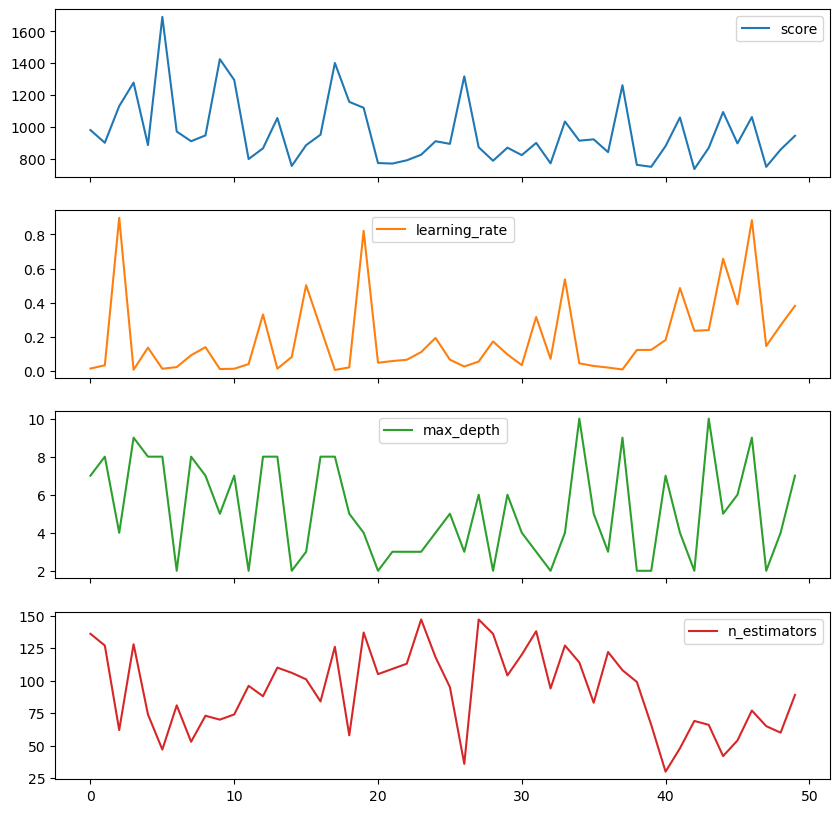

In [25]:
tpe_results = np.array(
    [
        [
            x["result"]["loss"],
            x["misc"]["vals"]["learning_rate"][0],
            x["misc"]["vals"]["max_depth"][0],
            x["misc"]["vals"]["n_estimators"][0],
        ]
        for x in trials.trials
    ]
)

tpe_results_df = pd.DataFrame(
    tpe_results, columns=["score", "learning_rate", "max_depth", "n_estimators"]
)
tpe_results_df.plot(subplots=True, figsize=(10, 10))
'''
rs_results_df=pd.DataFrame(np.transpose([-rs.cv_results_['mean_test_score'],
                                         rs.cv_results_['param_learning_rate'].data,
                                         rs.cv_results_['param_max_depth'].data,
                                         rs.cv_results_['param_n_estimators'].data]),
                           columns=['score', 'learning_rate', 'max_depth', 'n_estimators'])
rs_results_df.plot(subplots=True, figsize=(10, 10))
'''

# Simulated Anneal模拟退火算法

In [26]:
# possible values of parameters
'''
space={'n_estimators': hp.quniform('n_estimators', 1, 150, 1),
       'max_depth' : hp.quniform('max_depth', 2, 10, 1),
       'learning_rate': hp.loguniform('learning_rate', -5, 0)
      }'''
space={'n_estimators': hp.quniform('n_estimators', 30, 150, 1),
       'max_depth' : hp.quniform('max_depth', 2, 10, 1),
       'learning_rate': hp.loguniform('learning_rate', -5, 0),
       #'subsample': hp.quniform('subsample', 0.1, 1.0, 10),
       #'min_child_weight': hp.quniform('min_child_weight',1,7,4),
       #'colsample_bytree': hp.quniform('colsample_bytree',0.1, 1.0, 10), # subsample ratio of columns by tree
       #'max_delta_step': hp.quniform('max_delta_step',0.1, 1.0, 10),
       #'max_features':hp.choice('max_features',['auto','sqrt','log2',None]), 
      # 'gamma':hp.uniform('gamma',1,9),            
       #'reg_alpha': hp.quniform('reg_alpha',40, 100,1), # L1 regularization
       #'reg_lambda': hp.uniform('reg_lambda',0,1)# L2 regularization
      }

In [28]:
#Best MSE 3547.530 params {'colsample_bytree': 0.0, 'gamma': 8.946919502838902, 'learning_rate': 0.06992132555536061, 'max_delta_step': 0.0, 
#'max_depth': 9.0, 'min_child_weight': 0.0, 'n_estimators': 100.0, 'reg_alpha': 50.0, 'reg_lambda': 0.6536912918472014, 'subsample': 0.0}
# trials will contain logging information
trials = Trials()
#时间占用 s
start=timeit.default_timer()
#内存占用 mb
info_start = psutil.Process(os.getpid()).memory_info().rss/1024/1024
best=fmin(fn=gb_mse_cv, # function to optimize
          space=space, 
          algo=anneal.suggest, # optimization algorithm, hyperotp will select its parameters automatically
          max_evals=50, # maximum number of iterations
          trials=trials, # logging
          rstate=np.random.default_rng(random_state) # fixing random state for the reproducibility
         )
print('best:')
print(best)
# computing the score on the test set
model = AdaBoostRegressor(#random_state=3, n_estimators=96,max_depth=2,learning_rate=0.0832,
                    n_estimators=int(best['n_estimators']),max_depth=int(best['max_depth']),learning_rate=best['learning_rate'],
                  #subsample=best['subsample'],#colsample_bytree=best['colsample_bytree'], max_delta_step=best['max_delta_step'], 
                   #min_child_weight=best['min_child_weight'],#, max_features=best['max_features'],
                   #gamma=best['gamma'],  reg_alpha=best['reg_alpha'], reg_lambda=best['reg_lambda']
)
model.fit(train_data,train_targets)
sa_test_score=mean_squared_error(test_targets, model.predict(test_data))
end=timeit.default_timer()
info_end = psutil.Process(os.getpid()).memory_info().rss/1024/1024

print('此程序运行占内存'+str(info_end-info_start)+'mB')
print('Running time:%.5fs'%(end-start))
print("Best MSE {:.3f} params {}".format( gb_mse_cv(best), best))


980.6139861322746                                                                                                      
{'n_estimators': 136, 'max_depth': 7, 'learning_rate': 0.015495281324132052}                                           
982.7020977053864                                                                                                      
{'n_estimators': 98, 'max_depth': 4, 'learning_rate': 0.5668537374965246}                                              
933.6843406392638                                                                                                      
{'n_estimators': 119, 'max_depth': 4, 'learning_rate': 0.18383968050959204}                                            
901.659466150748                                                                                                       
{'n_estimators': 146, 'max_depth': 5, 'learning_rate': 0.1529866470670521}                                             
1140.5002584615522                      

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

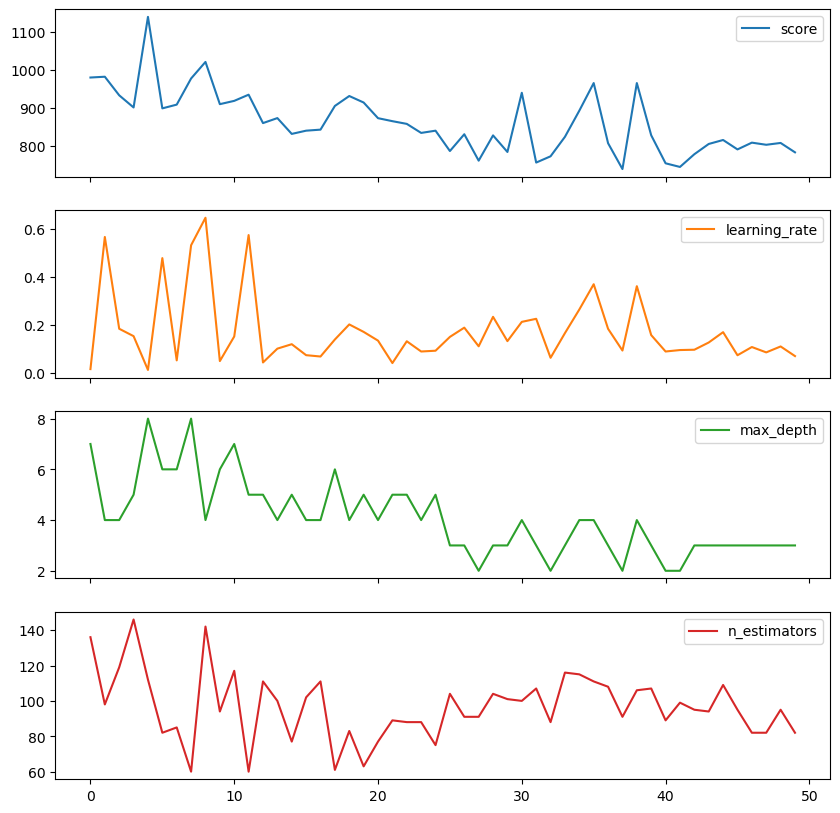

In [29]:
sa_results = np.array(
    [
        [
            x["result"]["loss"],
            x["misc"]["vals"]["learning_rate"][0],
            x["misc"]["vals"]["max_depth"][0],
            x["misc"]["vals"]["n_estimators"][0],
        ]
        for x in trials.trials
    ]
)

sa_results_df = pd.DataFrame(
    sa_results, columns=["score", "learning_rate", "max_depth", "n_estimators"]
)
sa_results_df.plot(subplots=True, figsize=(10, 10))

In [ ]:
# Results

Text(0, 0.5, 'best_cumulative_score')

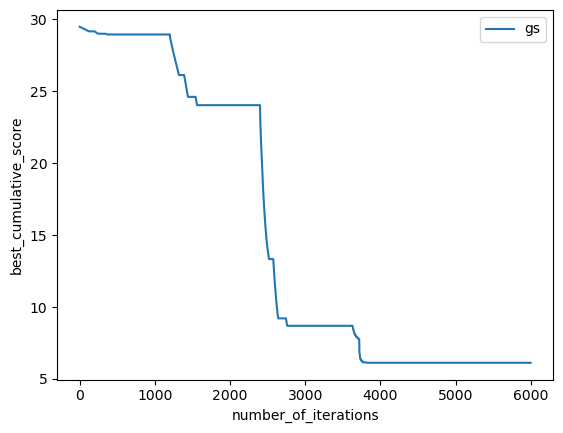

In [71]:
scores_df = pd.DataFrame(index=range(n_iter*120))
scores_df["gs"] = gs_results_df["score"].cummin()
ax = scores_df.plot()

ax.set_xlabel("number_of_iterations")
ax.set_ylabel("best_cumulative_score")

Text(0, 0.5, 'best_cumulative_score')

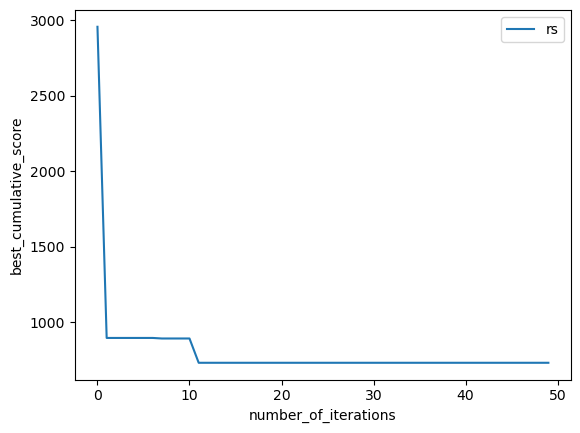

In [72]:
scores_df = pd.DataFrame(index=range(n_iter))
scores_df["rs"] = rs_results_df["score"].cummin()
ax = scores_df.plot()

ax.set_xlabel("number_of_iterations")
ax.set_ylabel("best_cumulative_score")

Text(0, 0.5, 'best_cumulative_score')

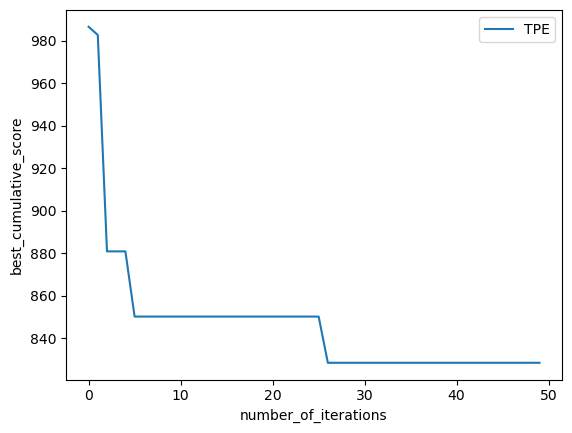

In [24]:
scores_df = pd.DataFrame(index=range(n_iter))
scores_df["TPE"] = tpe_results_df["score"].cummin()
ax = scores_df.plot()

ax.set_xlabel("number_of_iterations")
ax.set_ylabel("best_cumulative_score")

Text(0, 0.5, 'best_cumulative_score')

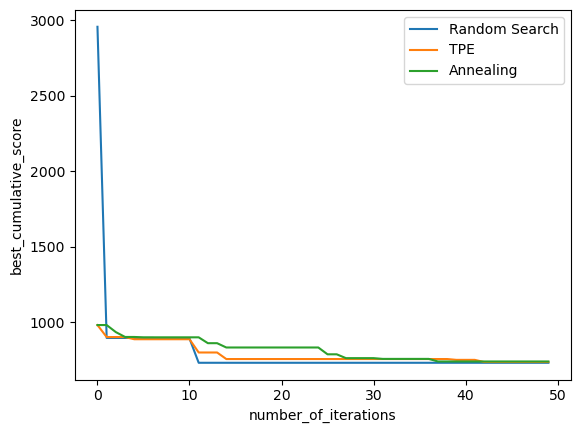

In [106]:
scores_df = pd.DataFrame(index=range(n_iter))
#scores_df["Grid Search"] = gs_results_df["score"].cummin()
scores_df["Random Search"] = rs_results_df["score"].cummin()
scores_df["TPE"] = tpe_results_df["score"].cummin()
scores_df["Annealing"] = sa_results_df["score"].cummin()

ax = scores_df.plot()

ax.set_xlabel("number_of_iterations")
ax.set_ylabel("best_cumulative_score")

In [105]:
scores_df

,rs
0,2956.533936
1,895.174180
2,895.174180
3,895.174180
4,895.174180
5,895.174180
6,895.174180
7,891.573714
8,891.573714
9,891.573714


In [77]:
scores_df_gs

,gs
0,29.483333
1,29.480693
2,29.478054
3,29.475416
4,29.472778
...,...
5995,6.123833
5996,6.123833
5997,6.123833
5998,6.123833


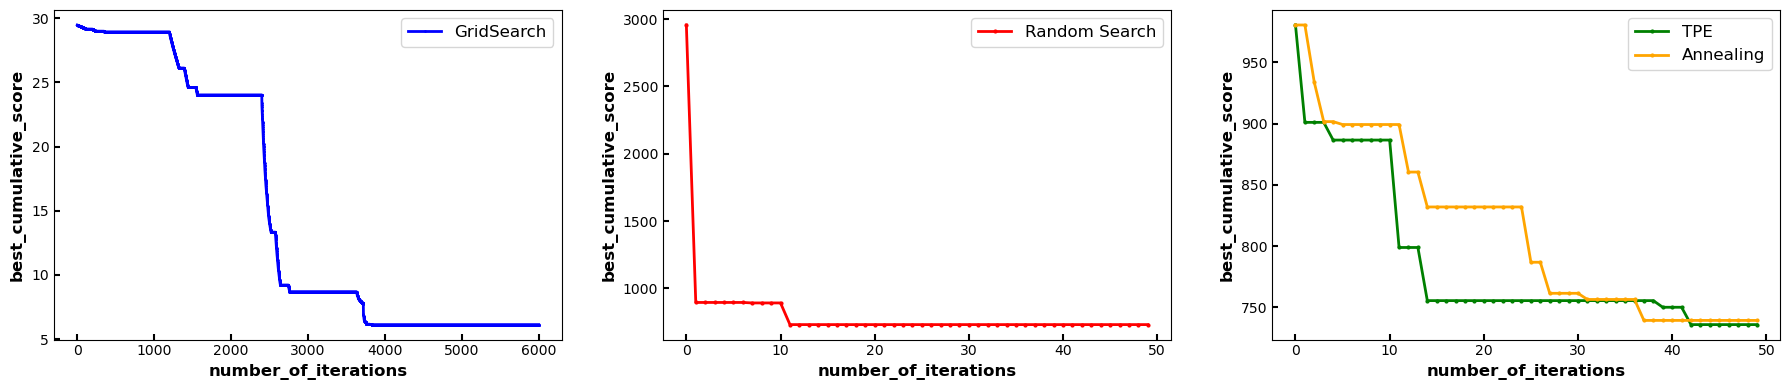

In [107]:
# 4. 创建一个图形窗口，包含多个子图
fig, ax = plt.subplots(1, 3, figsize=(18, 4))  # 3行1列的子图   #plt.figure(figsize=(18/2.54, 5/2.54),dpi=400)

# 网格优化
ax[0].plot(scores_df_gs.index,scores_df_gs['gs'] , label='GridSearch', color='blue', linewidth=2, marker='o', markersize=1)
# 设置标题和标签
ax[0].set_xlabel('number_of_iterations', fontsize=12, weight='bold')
ax[0].set_ylabel(r'best_cumulative_score', fontsize=12, weight='bold')
ax[0].legend(fontsize=12)
ax[0].tick_params(axis='both', which='both', direction='in', length=4, width=1.5)
#ax.grid(True, which='both', linestyle='--', linewidth=0.5)
# 随机优化
ax[1].plot(scores_df.index,scores_df["Random Search"] , label='Random Search', color='red', linewidth=2, marker='o', markersize=2)
# 设置标题和标签
# 设置标题和标签
ax[1].set_xlabel('number_of_iterations', fontsize=12, weight='bold')
ax[1].set_ylabel(r'best_cumulative_score', fontsize=12, weight='bold')
ax[1].legend(fontsize=12)
ax[1].tick_params(axis='both', which='both', direction='in', length=4, width=1.5)

# 贝叶斯优化
ax[2].plot(scores_df.index,scores_df["TPE"], label='TPE', color='green', linewidth=2, marker='o', markersize=2)
ax[2].plot(scores_df.index,scores_df["Annealing"], label='Annealing', color='orange', linewidth=2, marker='o', markersize=2)
# 设置标题和标签
# 设置标题和标签
ax[2].set_xlabel('number_of_iterations', fontsize=12, weight='bold')
ax[2].set_ylabel(r'best_cumulative_score', fontsize=12, weight='bold')
ax[2].legend(fontsize=12)
ax[2].tick_params(axis='both', which='both', direction='in', length=4, width=1.5)

# 设置图表的总体标题
#fig.suptitle('AdaBoost Regressor: MSE vs Hyperparameters', fontsize=8, weight='bold')

# 调整布局，防止标签被遮挡
plt.tight_layout()
plt.subplots_adjust(wspace=0.2)  # 调整整体标题的位置
#plt.subplots_adjust(left=0.125,bottom=-0.51,right=1.3,top=0.88,hspace=1.2)

# 保存为适合出版的图片格式
plt.savefig('AdaBoost_all_optimaztion_paras02170.png', dpi=400)
plt.show()

In [79]:
scores_df.index

RangeIndex(start=0, stop=50, step=1)

In [23]:
# Setting the basic regressor
xgb_reg = AdaBoostRegressor(random_state=0, booster='gbtree', objective='reg:squarederror', tree_method='gpu_hist')

# booster [default=gbtree]  gbtree: tree-based models  gblinear: linear models
# silent [default=0]   0,1
